# Valve: normal vs anomalous geometry (spectrogram + VQ latents)

Loads **valve** DCASE2020 Task 2 **test** clips and the **Stage 1** VQ-VAE checkpoint (fine + coarse codebooks). The test set is **stratified** by `machine_id` and label (normal vs anomalous).

We compare:
- **Spectrogram space**: mean log-mel per group and **per-bin** difference maps (anomaly mean minus normal mean) for each machine.
- **Two latent spaces** (quantized encoder outputs): **fine** `q_fine` and **coarse** `q_coarse` — spatial maps of $\|\mathbb{E}[q\mid\text{anom}]-\mathbb{E}[q\mid\text{norm}]\|_2$.


## 1. Paths and imports


In [1]:
import sys
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from torch.utils.data import DataLoader


def find_project_root() -> Path:
    p = Path.cwd().resolve()
    for _ in range(10):
        if (p / "src" / "data" / "dataset.py").is_file():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError("Could not find project root (src/data/dataset.py). Run from repo or notebooks/valve.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CKPT_DIR = PROJECT_ROOT / "checkpoints"
STAGE1_CKPT = (
    CKPT_DIR
    / "stage1"
    / "ToyCar+ToyConveyor+fan+pump+slider+valve"
    / "stage1_ToyCar+ToyConveyor+fan+pump+slider+valve_best.pt"
)

DATA_PATH = Path("/mnt/ssd/LaCie/dcase2020-task2-dev-dataset")
if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/ssd/LaCie/dcase2020_task2/dcase2020_task2_dev_dataset")
if not DATA_PATH.exists():
    DATA_PATH = PROJECT_ROOT / "data" / "dcase2020-task2-dev-dataset"
if not DATA_PATH.exists():
    DATA_PATH = PROJECT_ROOT / "data" / "dcase2020_task2_dev_dataset"
if not DATA_PATH.exists():
    DATA_PATH = Path("../../data/dcase2020-task2-dev-dataset").resolve()

MACHINE_TYPE = "valve"
BATCH_SIZE = 16
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_PATH: {DATA_PATH} (exists={DATA_PATH.exists()})")
print(f"STAGE1_CKPT: {STAGE1_CKPT} (exists={STAGE1_CKPT.exists()})")
print(f"Device: {DEVICE}")

PROJECT_ROOT: /home/lucash/Documents/NTUST/Research/papers/semantic-communication-networks/audDSR
DATA_PATH: /mnt/ssd/LaCie/dcase2020_task2/dcase2020_task2_dev_dataset (exists=True)
STAGE1_CKPT: /home/lucash/Documents/NTUST/Research/papers/semantic-communication-networks/audDSR/checkpoints/stage1/ToyCar+ToyConveyor+fan+pump+slider+valve/stage1_ToyCar+ToyConveyor+fan+pump+slider+valve_best.pt (exists=True)
Device: cuda


## 2. Load Stage 1 VQ-VAE and valve test set

`DCASE2020Task2TestDataset` returns standardized log-mel `(1, n_mels, T)` with `target_T` aligned to training (320).


In [2]:
from src.data.dataset import DCASE2020Task2TestDataset
from src.models.vq_vae.autoencoders import VQ_VAE_2Layer
from src.utils.checkpoint_compat import migrate_vq_vae_state_dict

if not STAGE1_CKPT.exists():
    raise FileNotFoundError(f"Missing checkpoint: {STAGE1_CKPT}")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Missing dataset root: {DATA_PATH}")

ckpt = torch.load(STAGE1_CKPT, map_location="cpu", weights_only=True)

n_mels, T = 128, 320
test_ds = DCASE2020Task2TestDataset(
    root=str(DATA_PATH),
    machine_type=MACHINE_TYPE,
    target_T=T,
)

num_embeddings_coarse = ckpt["num_embeddings_coarse"]
num_embeddings_fine = ckpt["num_embeddings_fine"]
embedding_dim_coarse = ckpt["embedding_dim_coarse"]
embedding_dim_fine = ckpt["embedding_dim_fine"]
hidden_channels_coarse = ckpt["hidden_channels_coarse"]
hidden_channels_fine = ckpt["hidden_channels_fine"]
num_residual_layers = ckpt["num_residual_layers"]

vq_vae = VQ_VAE_2Layer(
    hidden_channels=(hidden_channels_coarse, hidden_channels_fine),
    num_residual_layers=num_residual_layers,
    num_embeddings=(num_embeddings_coarse, num_embeddings_fine),
    embedding_dim=(embedding_dim_coarse, embedding_dim_fine),
    commitment_cost=0.25,
    decay=float(ckpt.get("decay", 0.99)),
)
state = dict(ckpt["model_state_dict"])
migrate_vq_vae_state_dict(state)
vq_vae.load_state_dict(state)
vq_vae = vq_vae.eval().to(DEVICE)

print(f"Test clips: {len(test_ds)} | n_mels={n_mels}, T={T}")
print(f"Fine grid q_fine: H={n_mels // 2}, W={T // 4}")
print(f"Coarse grid q_coarse: H={n_mels // 8}, W={T // 16}")


DCASE2020Task2TestDataset: valve | 879 clips | IDs: ['id_00', 'id_02', 'id_04', 'id_06']
Test clips: 879 | n_mels=128, T=320
Fine grid q_fine: H=64, W=80
Coarse grid q_coarse: H=16, W=20


## 3. Stratify by `machine_id` and label


In [3]:
grouped = defaultdict(lambda: {0: [], 1: []})
for idx in range(len(test_ds)):
    spec, label, machine_id = test_ds[idx]
    if spec.dim() == 3:
        spec = spec.unsqueeze(0)
    grouped[machine_id][int(label)].append((spec, idx))

print("Counts (normal / anomalous):")
for mid in sorted(grouped.keys()):
    n0, n1 = len(grouped[mid][0]), len(grouped[mid][1])
    print(f"  {mid}: normal={n0}, anomalous={n1}")


Counts (normal / anomalous):
  id_00: normal=100, anomalous=119
  id_02: normal=100, anomalous=120
  id_04: normal=100, anomalous=120
  id_06: normal=100, anomalous=120


## 4. Spectrogram: mean per group and per-bin difference (anom $-$ normal)

For each `machine_id` with both classes, we plot mean spectrograms and the **pixel-wise** difference of means.


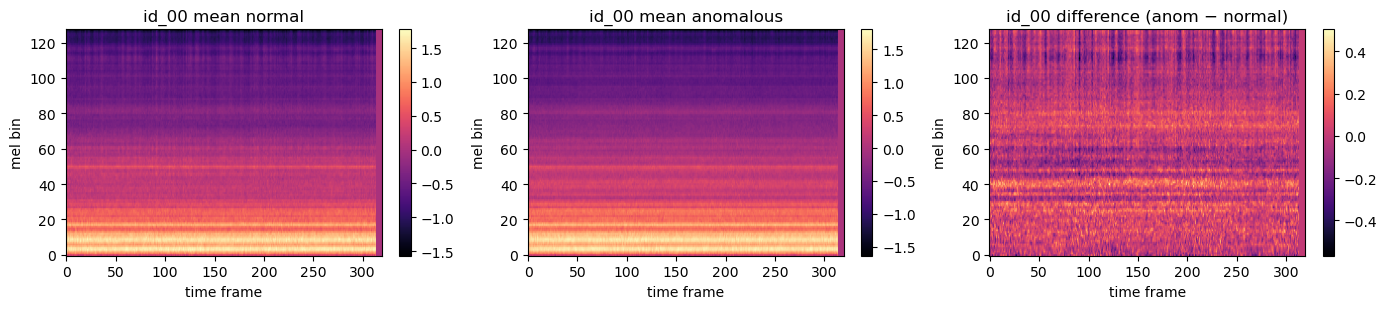

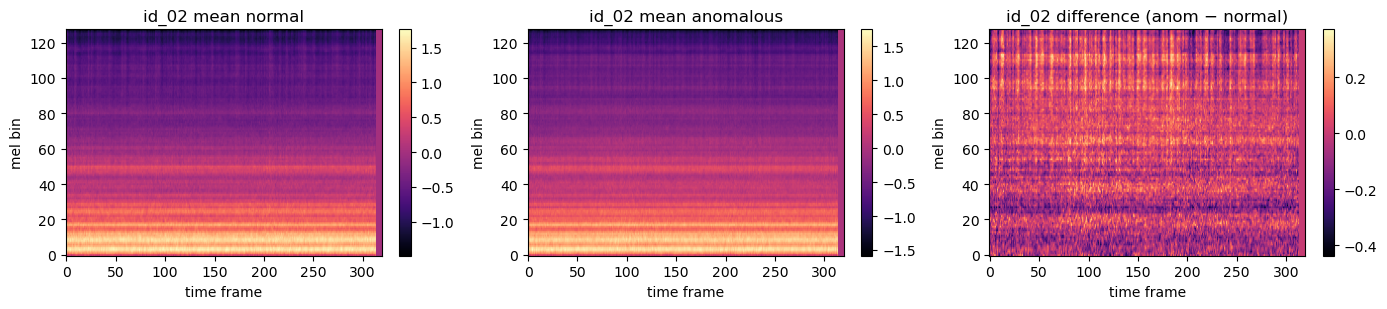

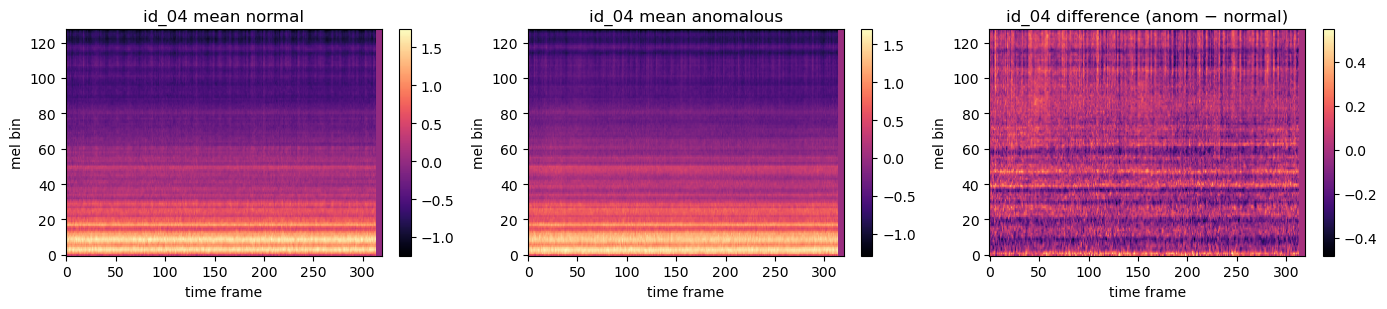

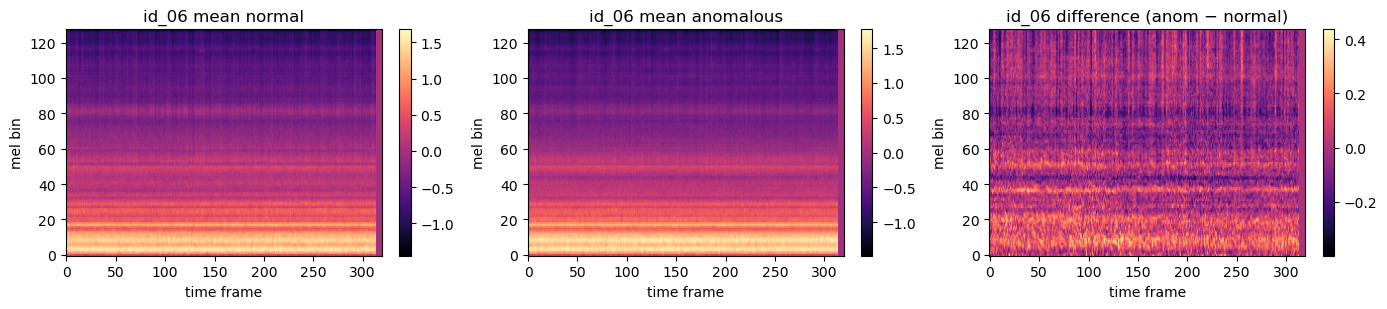

In [4]:
def mean_spec(spec_list):
    if not spec_list:
        return None
    stacked = torch.cat([s[0] for s in spec_list], dim=0)
    return stacked.mean(dim=0).squeeze(0).cpu().numpy()  # (n_mels, T)


fig_h = max(2.5, 1.2 * len(grouped))
for mid in sorted(grouped.keys()):
    norm = mean_spec(grouped[mid][0])
    anom = mean_spec(grouped[mid][1])
    if norm is None or anom is None:
        print(f"Skip {mid}: need both normal and anomalous clips.")
        continue
    diff = anom - norm
    vmax = float(max(abs(diff.min()), abs(diff.max()), 1e-6))
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.2))
    for ax, z, title in zip(
        axes,
        [norm, anom, diff],
        [f"{mid} mean normal", f"{mid} mean anomalous", f"{mid} difference (anom − normal)"],
    ):
        if title.endswith("difference"):
            im = ax.imshow(z, aspect="auto", origin="lower", cmap="coolwarm", norm=TwoSlopeNorm(0.0, vmin=-vmax, vmax=vmax))
            plt.colorbar(im, ax=ax, fraction=0.046)
        else:
            im = ax.imshow(z, aspect="auto", origin="lower", cmap="magma")
            plt.colorbar(im, ax=ax, fraction=0.046)
        ax.set_xlabel("time frame")
        ax.set_ylabel("mel bin")
        ax.set_title(title)
    plt.tight_layout()
    plt.show()


**Pooled valve view** — mean absolute difference map aggregated over all machine IDs (still per-bin):


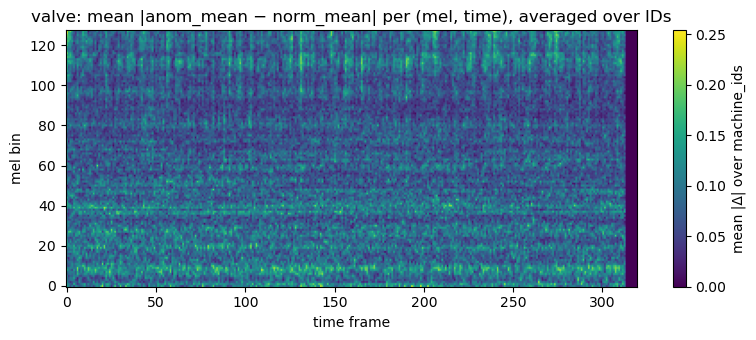

In [5]:
pairs = []
for mid in grouped:
    norm = mean_spec(grouped[mid][0])
    anom = mean_spec(grouped[mid][1])
    if norm is None or anom is None:
        continue
    pairs.append(anom - norm)
if pairs:
    stacked_diff = np.stack(pairs, axis=0)
    mean_abs = np.mean(np.abs(stacked_diff), axis=0)
    fig, ax = plt.subplots(figsize=(8, 3.5))
    im = ax.imshow(mean_abs, aspect="auto", origin="lower", cmap="viridis")
    plt.colorbar(im, ax=ax, label="mean |Δ| over machine_ids")
    ax.set_title("valve: mean |anom_mean − norm_mean| per (mel, time), averaged over IDs")
    ax.set_xlabel("time frame")
    ax.set_ylabel("mel bin")
    plt.tight_layout()
    plt.show()
else:
    print("No machine_id with both labels; skip pooled map.")


## 5. Encode full test set: `q_fine`, `q_coarse` (quantized latents)

Batched forward through `vq_vae.encode`.


In [6]:
loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

qf_list, qc_list, labels_list, mids_list = [], [], [], []
with torch.no_grad():
    for batch in loader:
        x, y, mids = batch
        x = x.to(DEVICE)
        q_fine, q_coarse = vq_vae.encode(x)
        qf_list.append(q_fine.cpu())
        qc_list.append(q_coarse.cpu())
        labels_list.append(y)
        mids_list.extend(mids if isinstance(mids, list) else list(mids))

Q_fine = torch.cat(qf_list, dim=0)
Q_coarse = torch.cat(qc_list, dim=0)
labels_t = torch.cat(labels_list, dim=0).long()
print("Q_fine:", tuple(Q_fine.shape), "Q_coarse:", tuple(Q_coarse.shape))

idx_by_mid_lab = defaultdict(lambda: {0: [], 1: []})
for i, mid in enumerate(mids_list):
    lab = int(labels_t[i].item())
    idx_by_mid_lab[mid][lab].append(i)


Q_fine: (879, 64, 32, 80) Q_coarse: (879, 128, 16, 40)


## 6. Latent space maps: $\|\mathbb{E}[q\mid \text{anom}] - \mathbb{E}[q\mid \text{norm}]\|_2$ per spatial bin

For each **fine** and **coarse** grid location we take the L2 norm across the embedding channel dimension.


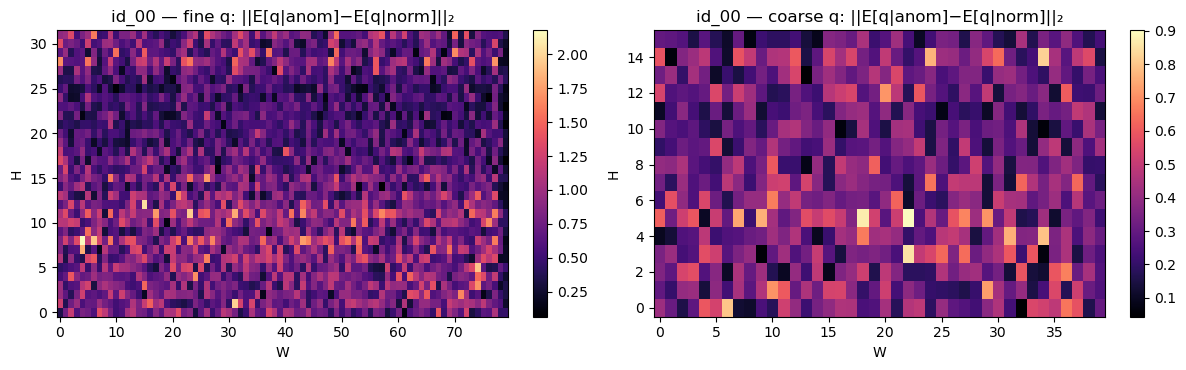

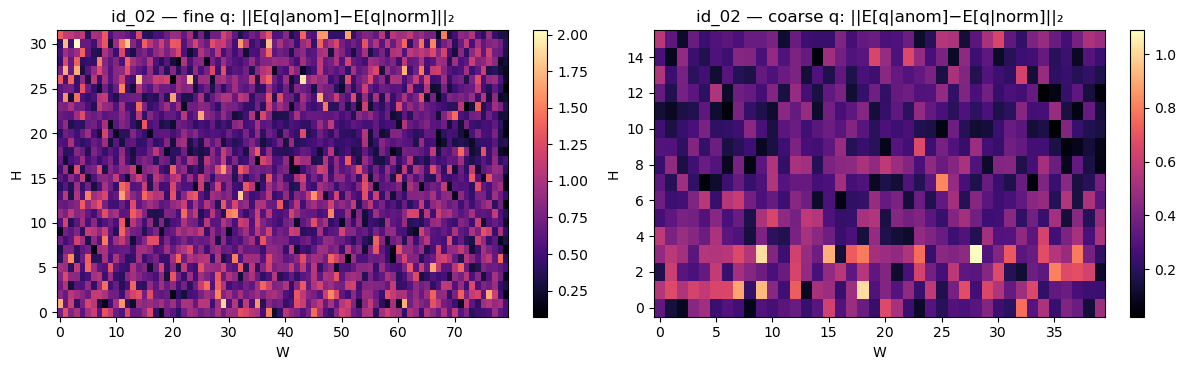

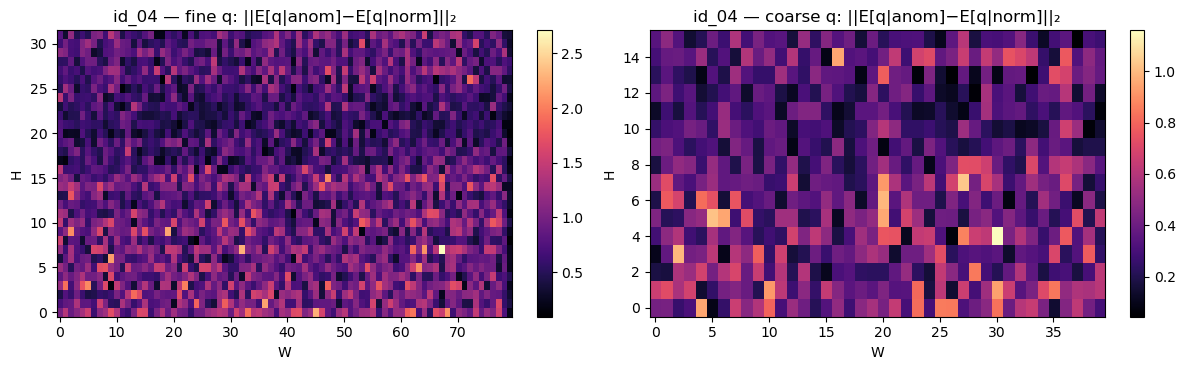

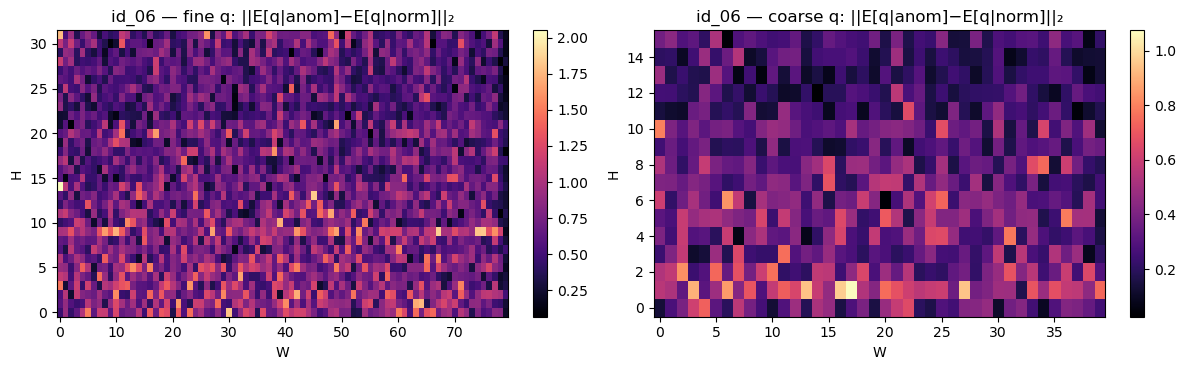

In [7]:
def mean_latent(indices, Q):
    if not indices:
        return None
    return Q[indices].mean(dim=0)  # (C, H, W)


def diff_map_l2(a, b):
    if a is None or b is None:
        return None
    return (a - b).pow(2).sum(dim=0).sqrt().numpy()  # (H, W)


for mid in sorted(idx_by_mid_lab.keys()):
    i0 = idx_by_mid_lab[mid][0]
    i1 = idx_by_mid_lab[mid][1]
    if not i0 or not i1:
        print(f"Skip {mid}: need both labels in encoded batch.")
        continue
    mf0, mf1 = mean_latent(i0, Q_fine), mean_latent(i1, Q_fine)
    mc0, mc1 = mean_latent(i0, Q_coarse), mean_latent(i1, Q_coarse)
    df = diff_map_l2(mf1, mf0)
    dc = diff_map_l2(mc1, mc0)
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    im0 = axes[0].imshow(df, aspect="auto", origin="lower", cmap="magma")
    axes[0].set_title(f"{mid} — fine q: ||E[q|anom]−E[q|norm]||₂")
    plt.colorbar(im0, ax=axes[0], fraction=0.046)
    im1 = axes[1].imshow(dc, aspect="auto", origin="lower", cmap="magma")
    axes[1].set_title(f"{mid} — coarse q: ||E[q|anom]−E[q|norm]||₂")
    plt.colorbar(im1, ax=axes[1], fraction=0.046)
    for ax in axes:
        ax.set_xlabel("W")
        ax.set_ylabel("H")
    plt.tight_layout()
    plt.show()


## 7. VQ-VAE-level diagnostics: can Stage 1 alone separate normal from anomalous?

Three per-sample scalar signals are computed and compared (normal vs anomalous) for each `machine_id`:

1. **Reconstruction MSE** $\|x - \hat x\|^2$ — if anomalies reconstruct differently, Stage 1 already carries signal.
2. **Quantization error (fine / coarse)** $\|z - q\|^2$ — if anomalous features land further from codebook entries, the quantization step itself introduces a detectable distortion.
3. **Codebook index overlap (Jaccard)** — measures how much the set of codebook entries used by normals overlaps with anomalies.  High overlap means the codebook can't distinguish them.

If *none* of these signals separate normal from anomalous for a given ID, Stage 2 has no latent-space signal to amplify.

id_00: fine JSD signal=0.8825 null=0.9403  coarse JSD signal=0.7683 null=0.8680
id_02: fine JSD signal=0.8836 null=0.9389  coarse JSD signal=0.7684 null=0.8675
id_04: fine JSD signal=0.8885 null=0.9425  coarse JSD signal=0.7841 null=0.8803
id_06: fine JSD signal=0.8844 null=0.9419  coarse JSD signal=0.7769 null=0.8783


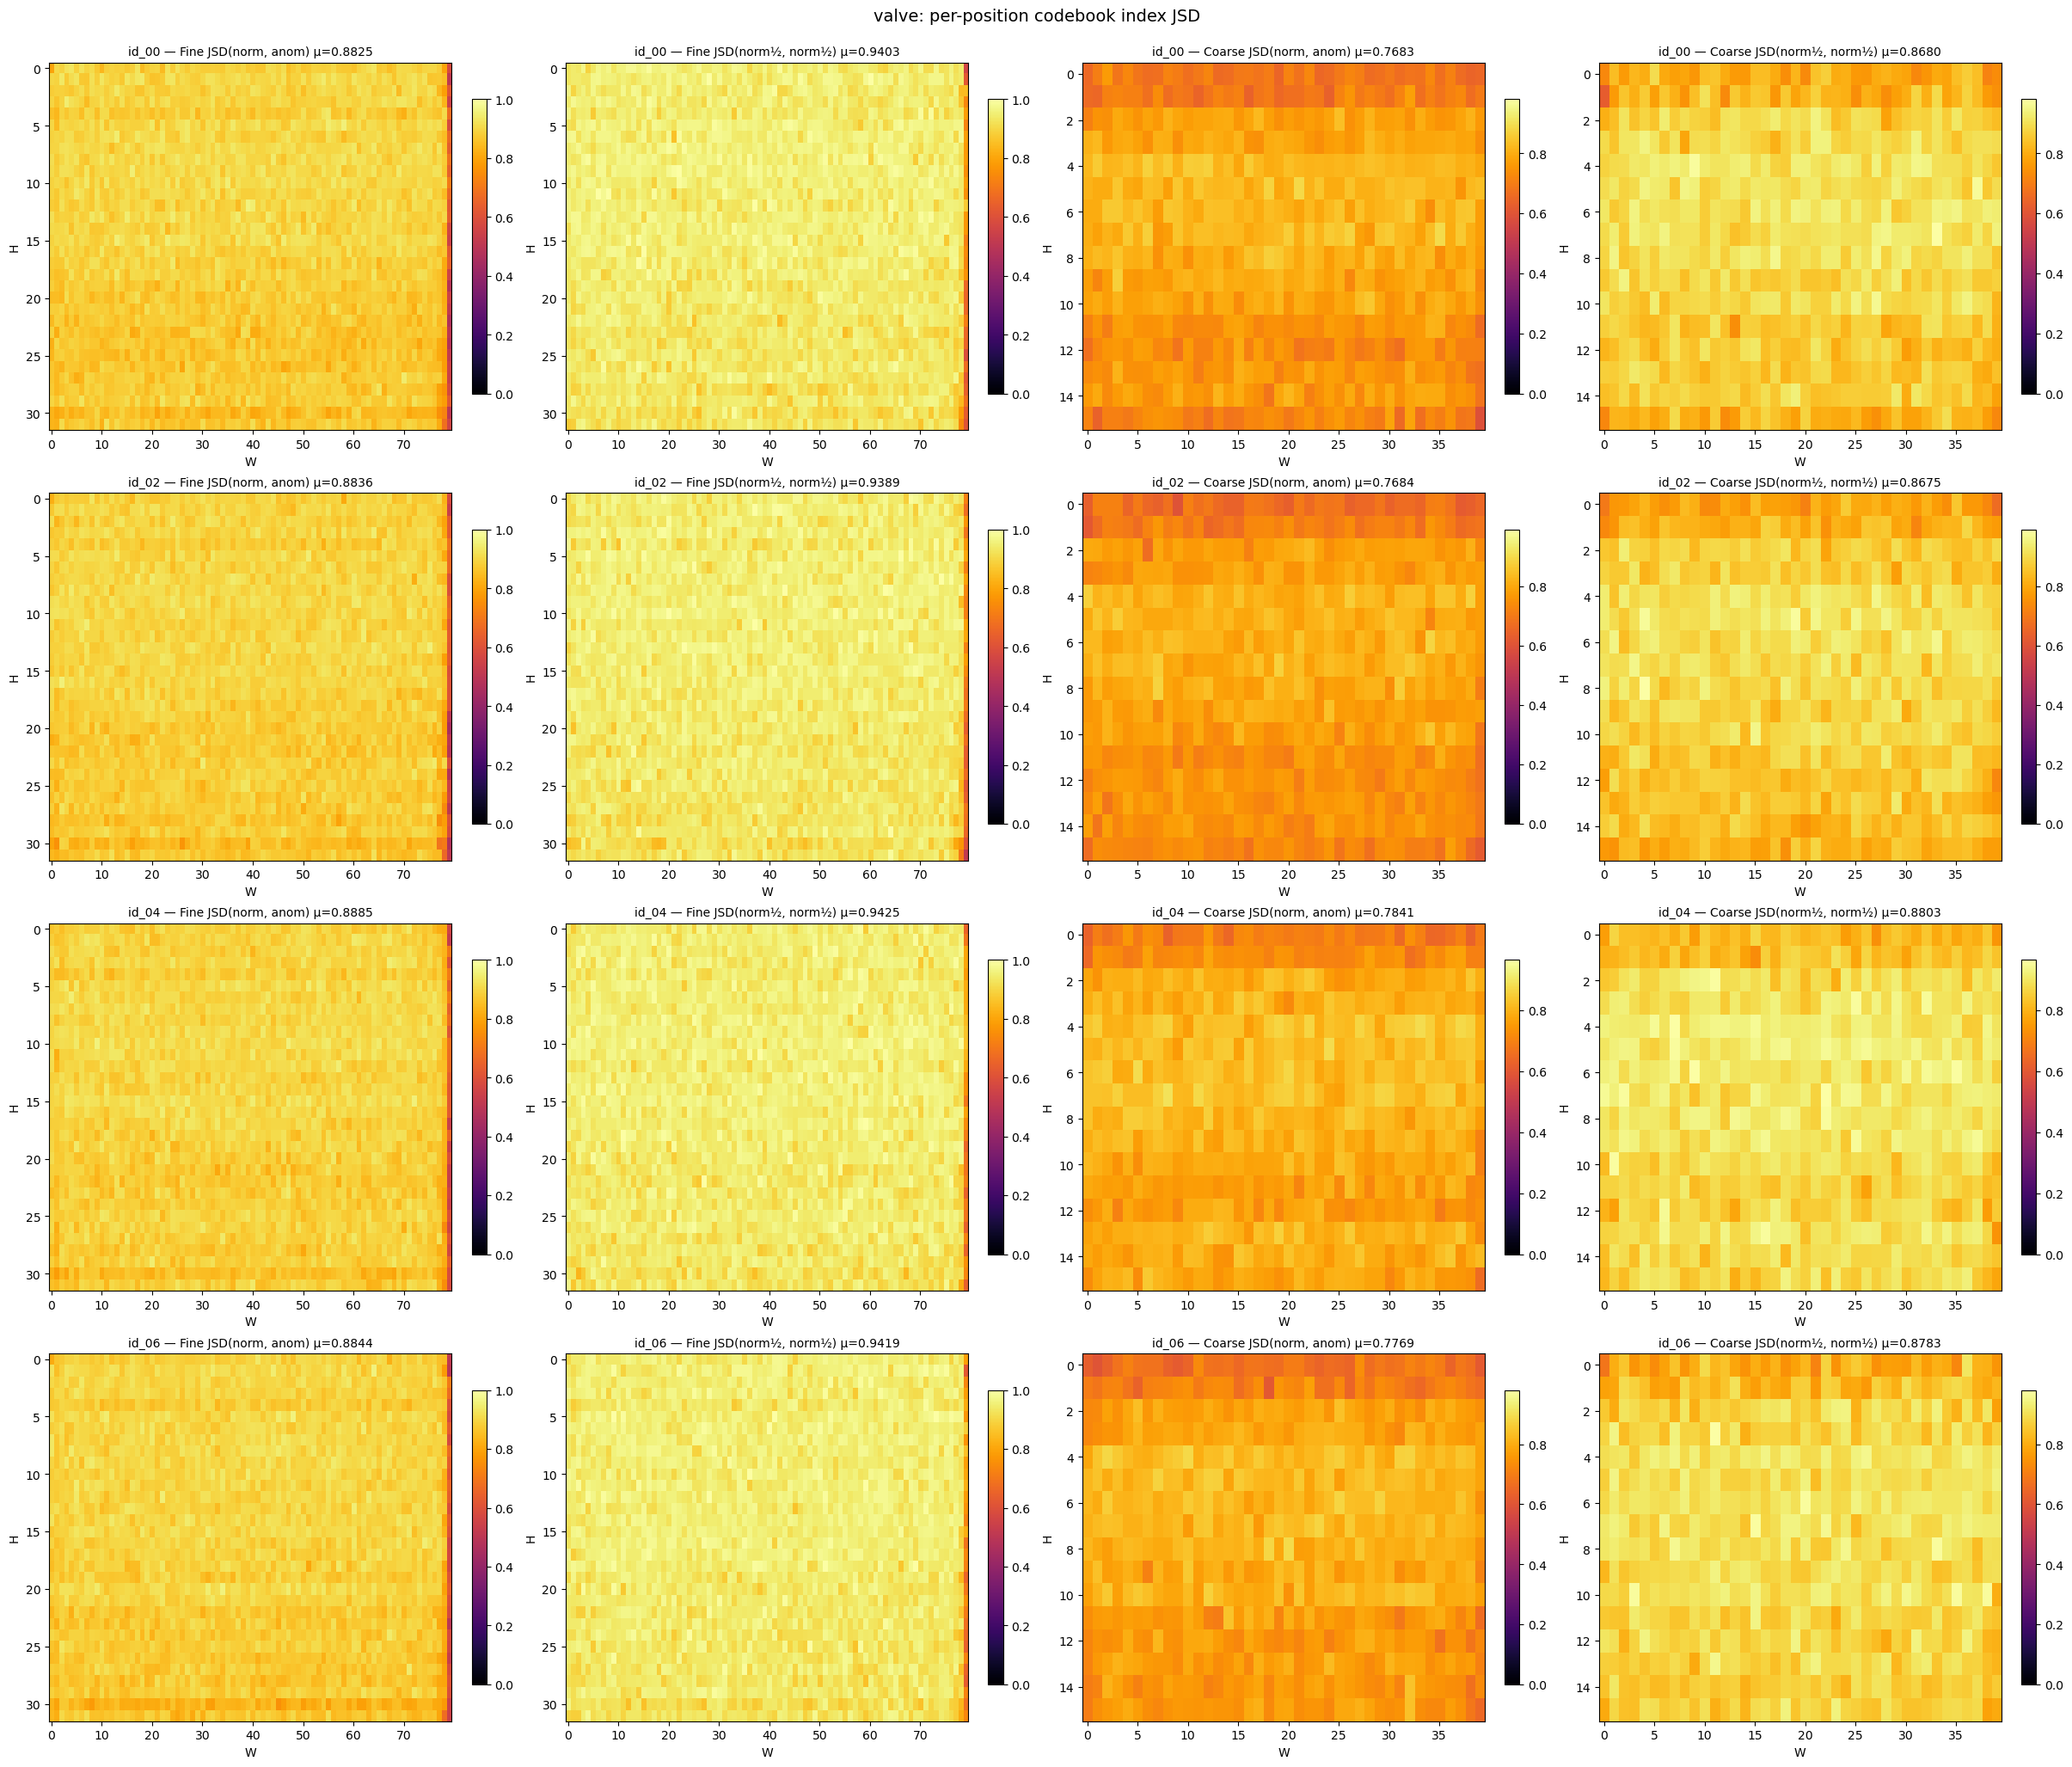

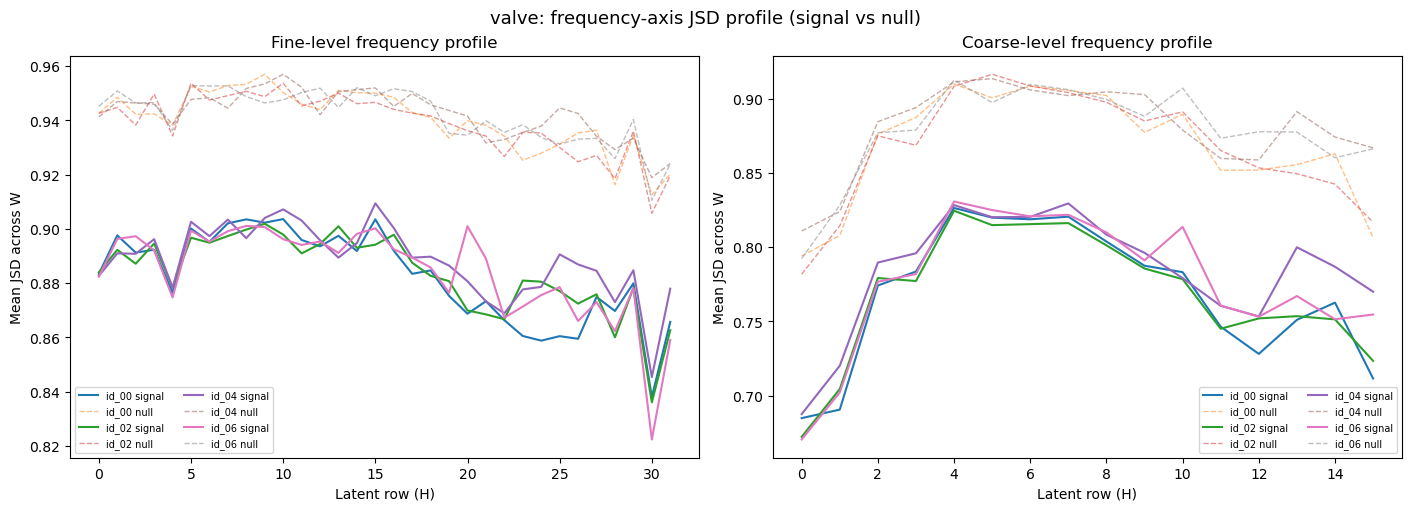


ID         Fine sig   Fine null    SNR   Coarse sig   Coarse null    SNR   #disc fine   #disc coarse
id_00        0.8825      0.9403   0.9x       0.7683        0.8680   0.9x      0/2560         0/640  
id_02        0.8836      0.9389   0.9x       0.7684        0.8675   0.9x      0/2560         0/640  
id_04        0.8885      0.9425   0.9x       0.7841        0.8803   0.9x      0/2560         0/640  
id_06        0.8844      0.9419   0.9x       0.7769        0.8783   0.9x      0/2560         0/640  


In [9]:
# --- Encode full test set to codebook indices ---
_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
idx_fine_all, idx_coarse_all = [], []

with torch.no_grad():
    for x, _y, _m in _loader:
        x = x.to(DEVICE)
        ic, if_ = vq_vae.encode_to_indices(x)
        idx_coarse_all.append(ic.cpu())
        idx_fine_all.append(if_.cpu())

IDX_fine   = torch.cat(idx_fine_all).numpy()    # (N, H_fine, W_fine)
IDX_coarse = torch.cat(idx_coarse_all).numpy()  # (N, H_coarse, W_coarse)
K_fine   = num_embeddings_fine
K_coarse = num_embeddings_coarse


def position_jsd_map(indices_a, indices_b, K):
    """JSD (base-2) between index distributions at each spatial position."""
    H, W = indices_a.shape[1], indices_a.shape[2]
    jsd = np.zeros((H, W), dtype=np.float64)
    for h in range(H):
        for w in range(W):
            pa = np.bincount(indices_a[:, h, w], minlength=K)[:K].astype(np.float64)
            pb = np.bincount(indices_b[:, h, w], minlength=K)[:K].astype(np.float64)
            pa /= pa.sum() + 1e-15
            pb /= pb.sum() + 1e-15
            m = 0.5 * (pa + pb)
            with np.errstate(divide="ignore", invalid="ignore"):
                kl_pm = np.where(pa > 0, pa * np.log2(pa / np.clip(m, 1e-15, None)), 0.0)
                kl_qm = np.where(pb > 0, pb * np.log2(pb / np.clip(m, 1e-15, None)), 0.0)
            jsd[h, w] = np.sqrt(np.clip(0.5 * kl_pm.sum() + 0.5 * kl_qm.sum(), 0, None))
    return jsd


# --- Compute JSD maps per ID (signal + within-normal null) ---
machine_ids = sorted(idx_by_mid_lab.keys())
n_ids = len(machine_ids)
rng = np.random.RandomState(42)

results = {}
for mid in machine_ids:
    ni = np.array(idx_by_mid_lab[mid][0])
    ai = np.array(idx_by_mid_lab[mid][1])
    jsd_f = position_jsd_map(IDX_fine[ni], IDX_fine[ai], K_fine)
    jsd_c = position_jsd_map(IDX_coarse[ni], IDX_coarse[ai], K_coarse)
    perm = rng.permutation(len(ni))
    h = len(perm) // 2
    jsd_fn = position_jsd_map(IDX_fine[ni[perm[:h]]], IDX_fine[ni[perm[h:]]], K_fine)
    jsd_cn = position_jsd_map(IDX_coarse[ni[perm[:h]]], IDX_coarse[ni[perm[h:]]], K_coarse)
    results[mid] = dict(jsd_f=jsd_f, jsd_c=jsd_c, jsd_fn=jsd_fn, jsd_cn=jsd_cn)
    print(f"{mid}: fine JSD signal={jsd_f.mean():.4f} null={jsd_fn.mean():.4f}  "
          f"coarse JSD signal={jsd_c.mean():.4f} null={jsd_cn.mean():.4f}")


# --- 2-D spatial maps: signal vs null ---
fig, axes = plt.subplots(n_ids, 4, figsize=(24, 5 * n_ids), constrained_layout=True)
if n_ids == 1:
    axes = axes[np.newaxis, :]

for row, mid in enumerate(machine_ids):
    r = results[mid]
    vmax_f = max(r["jsd_f"].max(), r["jsd_fn"].max(), 1e-3)
    vmax_c = max(r["jsd_c"].max(), r["jsd_cn"].max(), 1e-3)

    for col, (data, vmax, title) in enumerate([
        (r["jsd_f"],  vmax_f, f"Fine JSD(norm, anom) μ={r['jsd_f'].mean():.4f}"),
        (r["jsd_fn"], vmax_f, f"Fine JSD(norm½, norm½) μ={r['jsd_fn'].mean():.4f}"),
        (r["jsd_c"],  vmax_c, f"Coarse JSD(norm, anom) μ={r['jsd_c'].mean():.4f}"),
        (r["jsd_cn"], vmax_c, f"Coarse JSD(norm½, norm½) μ={r['jsd_cn'].mean():.4f}"),
    ]):
        ax = axes[row, col]
        im = ax.imshow(data, aspect="auto", cmap="inferno", vmin=0, vmax=vmax)
        ax.set_title(f"{mid} — {title}", fontsize=10)
        ax.set_xlabel("W"); ax.set_ylabel("H")
        fig.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle(f"{MACHINE_TYPE}: per-position codebook index JSD", fontsize=14, y=1.02)
plt.show()


# --- Row-wise (frequency) profile: mean JSD across time ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for ax, level, key_s, key_n in [
    (axes[0], "Fine",   "jsd_f", "jsd_fn"),
    (axes[1], "Coarse", "jsd_c", "jsd_cn"),
]:
    for mid in machine_ids:
        profile = results[mid][key_s].mean(axis=1)
        null    = results[mid][key_n].mean(axis=1)
        ax.plot(profile, label=f"{mid} signal", linewidth=1.5)
        ax.plot(null, label=f"{mid} null", linewidth=1.0, linestyle="--", alpha=0.5)
    ax.set_xlabel("Latent row (H)")
    ax.set_ylabel("Mean JSD across W")
    ax.set_title(f"{level}-level frequency profile")
    ax.legend(fontsize=7, ncol=2)
plt.suptitle(f"{MACHINE_TYPE}: frequency-axis JSD profile (signal vs null)", fontsize=13)
plt.show()


# --- Summary table ---
print(f"\n{'ID':<8} {'Fine sig':>10} {'Fine null':>11} {'SNR':>6} "
      f"{'Coarse sig':>12} {'Coarse null':>13} {'SNR':>6} "
      f"{'#disc fine':>12} {'#disc coarse':>14}")
for mid in machine_ids:
    r = results[mid]
    snr_f = r["jsd_f"].mean() / max(r["jsd_fn"].mean(), 1e-8)
    snr_c = r["jsd_c"].mean() / max(r["jsd_cn"].mean(), 1e-8)
    disc_f = int((r["jsd_f"] > 2 * r["jsd_fn"].mean()).sum())
    disc_c = int((r["jsd_c"] > 2 * r["jsd_cn"].mean()).sum())
    tot_f  = r["jsd_f"].size
    tot_c  = r["jsd_c"].size
    print(f"{mid:<8} {r['jsd_f'].mean():>10.4f} {r['jsd_fn'].mean():>11.4f} {snr_f:>5.1f}x "
          f"{r['jsd_c'].mean():>12.4f} {r['jsd_cn'].mean():>13.4f} {snr_c:>5.1f}x "
          f"{disc_f:>6d}/{tot_f:<5d} {disc_c:>8d}/{tot_c:<5d}")